# 06 — Model Application: Scoring the Zindi Test Clients

`05_final_model.ipynb` froze a modelling recipe (preprocessing variant, LightGBM
hyperparameters, ensemble go/no-go) using only cross-validation evidence, checked it exactly
once on a genuinely held-out slice of the *labelled* data, and persisted the result (Step 8)
to `models/`. This notebook is the actual deliverable for the
[Zindi fraud-detection challenge](https://zindi.world/competitions/fraud-detection-in-electricity-and-gas-consumption-challenge):
it applies that frozen, persisted model to the real competition test clients
(`data/parquet/client_test.parquet` + `invoice_test.parquet`) — clients with no fraud label at
all, held by Zindi, not by us — and produces the submission file in Zindi's required format.

**What this notebook can and can't tell you about performance:** the test clients have no
label available to us locally, so there is no way to compute a true PR-AUC/ROC-AUC for them
here — that number only exists on Zindi's servers, and appears once you submit. What Step 4
below reports instead is (a) the frozen model's honest, one-time holdout performance from
`05` — our best available estimate of how it will do on genuinely new clients — restated from
the persisted metadata, plus (b) descriptive diagnostics of what the model actually predicted
for these specific test clients, which is a real check on the *predictions* even though it
can't validate their *correctness*.

**Zindi submission contract** (confirmed directly from the challenge page): exactly two
columns, `client_id` and `target`, where `target` is a fraud **probability** (e.g. `0.986`),
not a 0/1 label, scored by AUC on Zindi's hidden test labels.

## Imports and setup

In [1]:
import json
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
from IPython.display import display
from joblib import load
from sklearn import set_config

pd.set_option("display.max_columns", 100)
# Must match 05_final_model.ipynb's own config -- it stayed set for that entire kernel
# session, including the holdout evaluation this notebook restates. Without it, the
# ColumnTransformer step returns a plain numpy array instead of a DataFrame, the LightGBM
# step loses the pandas "category" dtype on client_catg/region/disrict, and predictions
# for the native-categorical variant come out silently wrong (verified: >0.3 absolute
# probability difference on real test rows without this line).
set_config(transform_output="pandas")

DATA_DIR = Path("data")
PARQUET_DIR = DATA_DIR / "parquet"
MODELS_DIR = Path("models")
SUBMISSIONS_DIR = DATA_DIR / "processed"

CLIENT_TEST_PATH = PARQUET_DIR / "client_test.parquet"
INVOICE_TEST_PATH = PARQUET_DIR / "invoice_test.parquet"
MODEL_PATH = MODELS_DIR / "final_model_pipeline.joblib"
METADATA_PATH = MODELS_DIR / "final_model_metadata.json"

for required_path in [CLIENT_TEST_PATH, INVOICE_TEST_PATH, MODEL_PATH, METADATA_PATH]:
    if not required_path.exists():
        raise FileNotFoundError(
            f"{required_path} is missing. If it's under models/, run 05_final_model.ipynb's "
            "Step 8 first -- this notebook only *applies* the frozen model, it doesn't train one."
        )

## Step 1 — Load the frozen model and its metadata

Both files were written by `05_final_model.ipynb`'s Step 8. `final_model_metadata.json` records
exactly which preprocessing variant won, the frozen LightGBM hyperparameters, whether the
ensemble was adopted, the feature contract, and the honest holdout metrics from `05` -- nothing
here is re-derived or hardcoded, it's read straight from what `05` already established.

In [2]:
with open(METADATA_PATH) as f:
    model_metadata = json.load(f)

deployment_artifacts = load(MODEL_PATH)

print(f"Frozen model     : {model_metadata['final_model_name']}")
print(f"Preprocessing    : {model_metadata['winning_variant']}")
print(f"Ensemble adopted : {model_metadata['adopt_ensemble']}")
print(f"Loaded pipelines : {list(deployment_artifacts.keys())}")
print(f"\n05's one-time holdout evaluation of this frozen recipe:")
print(f"  PR-AUC:  {model_metadata['holdout_pr_auc']:.4f}")
print(f"  ROC-AUC: {model_metadata['holdout_roc_auc']:.4f}")
print(f"  (holdout fraud rate: {model_metadata['holdout_base_rate']:.4%})")
display(pd.Series(model_metadata["best_params"]).rename("value").to_frame())

Frozen model     : LightGBM (tuned)
Preprocessing    : native categorical
Ensemble adopted : False
Loaded pipelines : ['lightgbm']

05's one-time holdout evaluation of this frozen recipe:
  PR-AUC:  0.2647
  ROC-AUC: 0.8354
  (holdout fraud rate: 5.5832%)


,value
subsample,1.00
reg_lambda,5.00
reg_alpha,5.00
num_leaves,127.00
n_estimators,300.00
min_child_samples,50.00
max_depth,-1.00
learning_rate,0.03
colsample_bytree,1.00


## Step 2 — Build the same 15 features for the test clients

`01_eda.ipynb` built `df_training.csv`'s features with three streaming aggregation functions
over `invoice_train.parquet` (`aggregate_invoices`, `aggregate_meter_submissions`,
`audit_meter_reconciliation`) plus a left-merge onto `client_train.parquet`. `01_eda.ipynb`
itself documents (but never executes) applying the exact same functions to
`client_test.parquet`/`invoice_test.parquet` -- this step is that documented-but-unrun example,
actually run. The functions below are copied verbatim from `01_eda.ipynb` (not re-derived) so
the test features are computed identically to the training features: no test-set-specific
fitting happens anywhere in this step (no imputer/scaler/encoder here, just the same raw
aggregation arithmetic), so there is no leakage risk in this cell -- leakage only becomes a risk
once statistics get *fit*, and that already happened back in `05`, on labelled data only.

Both streaming functions assume invoice rows arrive grouped by `client_id` in the Parquet file
(same assumption `01_eda.ipynb` relies on for the training data) and raise a `ValueError`
themselves if that assumption is violated -- so a clean run through this cell is itself a
verification that the assumption holds for `invoice_test.parquet` too, not something taken on
faith.

In [3]:
CONSUMPTION_COLUMNS = [f"consommation_level_{level}" for level in range(1, 5)]


def aggregate_invoices(path, chunk_size=250_000, as_of_date=None):
    partials = []
    cutoff = pd.Timestamp(as_of_date) if as_of_date is not None else None
    total_rows = 0

    parquet_file = pq.ParquetFile(path)
    for chunk_number, batch in enumerate(parquet_file.iter_batches(batch_size=chunk_size), start=1):
        chunk = batch.to_pandas()
        chunk["client_id"] = chunk["client_id"].astype("string")
        chunk["invoice_date"] = pd.to_datetime(chunk["invoice_date"], errors="raise")
        if cutoff is not None:
            chunk = chunk.loc[~chunk["invoice_date"].gt(cutoff)].copy()
        total_rows += len(chunk)

        chunk["total_consumption"] = chunk[CONSUMPTION_COLUMNS].sum(axis=1)
        chunk["index_delta"] = chunk["new_index"] - chunk["old_index"]
        chunk["zero_consumption"] = chunk["total_consumption"].eq(0).astype("int8")
        chunk["is_elec"] = chunk["counter_type"].eq("ELEC").astype("int8")
        chunk["index_went_backwards"] = chunk["index_delta"].lt(0).astype("int8")
        chunk["valid_billing_months"] = chunk["months_number"].between(1, 24)
        chunk["billed_months"] = chunk["months_number"].where(chunk["valid_billing_months"])
        chunk["index_delta_for_valid_months"] = chunk["index_delta"].where(chunk["valid_billing_months"])

        grouped = chunk.groupby("client_id", observed=True).agg(
            invoice_count=("client_id", "size"),
            first_invoice=("invoice_date", "min"),
            last_invoice=("invoice_date", "max"),
            total_consumption_sum=("total_consumption", "sum"),
            index_delta_sum=("index_delta", "sum"),
            months_sum=("months_number", "sum"),
            zero_consumption_count=("zero_consumption", "sum"),
            elec_invoice_count=("is_elec", "sum"),
            backwards_index_count=("index_went_backwards", "sum"),
            valid_billing_invoice_count=("valid_billing_months", "sum"),
            billed_months_sum=("billed_months", "sum"),
            index_delta_valid_months_sum=("index_delta_for_valid_months", "sum"),
        )
        partials.append(grouped.reset_index())
        if chunk_number % 5 == 0:
            print(f"  invoices: processed {total_rows:,} rows...")

    partial = pd.concat(partials, ignore_index=True)
    client_agg = partial.groupby("client_id", as_index=False).agg(
        invoice_count=("invoice_count", "sum"),
        first_invoice=("first_invoice", "min"),
        last_invoice=("last_invoice", "max"),
        total_consumption_sum=("total_consumption_sum", "sum"),
        index_delta_sum=("index_delta_sum", "sum"),
        months_sum=("months_sum", "sum"),
        zero_consumption_count=("zero_consumption_count", "sum"),
        elec_invoice_count=("elec_invoice_count", "sum"),
        backwards_index_count=("backwards_index_count", "sum"),
        valid_billing_invoice_count=("valid_billing_invoice_count", "sum"),
        billed_months_sum=("billed_months_sum", "sum"),
        index_delta_valid_months_sum=("index_delta_valid_months_sum", "sum"),
    )

    # Invoice-date gaps, streamed the same way 01_eda.ipynb does: rows are grouped by client in
    # this Parquet file, so only one client's dates need to be held in memory at a time. Raises
    # ValueError itself if that grouping assumption turns out not to hold for this file.
    gap_rows, closed_client_ids = [], set()
    current_client_id, current_date_parts = None, []

    def finish_current_client():
        if current_client_id is None:
            return
        dates = np.sort(np.concatenate(current_date_parts))
        if len(dates) < 2:
            gap_rows.append({"client_id": current_client_id, "mean_invoice_gap_days": 0.0})
            return
        gap_days = np.diff(dates).astype("timedelta64[D]").astype(int)
        gap_rows.append({"client_id": current_client_id, "mean_invoice_gap_days": gap_days.mean()})

    gap_reader = pq.ParquetFile(path).iter_batches(batch_size=chunk_size, columns=["client_id", "invoice_date"])
    for gap_batch in gap_reader:
        gap_frame = gap_batch.to_pandas()
        gap_frame["invoice_date"] = pd.to_datetime(gap_frame["invoice_date"], errors="raise")
        for client_id, group in gap_frame.groupby("client_id", sort=False):
            client_dates = group["invoice_date"].dropna().to_numpy(dtype="datetime64[ns]")
            if current_client_id is None:
                current_client_id, current_date_parts = client_id, [client_dates]
            elif client_id == current_client_id:
                current_date_parts.append(client_dates)
            else:
                finish_current_client()
                closed_client_ids.add(current_client_id)
                if client_id in closed_client_ids:
                    raise ValueError("Invoice rows are not grouped by client; cannot calculate gaps safely.")
                current_client_id, current_date_parts = client_id, [client_dates]
    finish_current_client()

    client_agg = client_agg.merge(pd.DataFrame(gap_rows), on="client_id", how="left", validate="one_to_one")
    client_agg["mean_consumption"] = client_agg["total_consumption_sum"] / client_agg["invoice_count"]
    client_agg["zero_consumption_rate"] = client_agg["zero_consumption_count"] / client_agg["invoice_count"]
    client_agg["elec_share"] = client_agg["elec_invoice_count"] / client_agg["invoice_count"]
    client_agg["active_days"] = (client_agg["last_invoice"] - client_agg["first_invoice"]).dt.days
    client_agg["backwards_index_rate"] = client_agg["backwards_index_count"] / client_agg["invoice_count"]
    return client_agg, {"invoice_rows": total_rows, "invoice_clients": client_agg["client_id"].nunique()}


def aggregate_meter_submissions(path, chunk_size=250_000, as_of_date=None):
    client_summaries, closed_client_ids = [], set()
    carry_over = pd.DataFrame()
    cutoff = pd.Timestamp(as_of_date) if as_of_date is not None else None

    def summarise_complete_clients(readings):
        completed_ids = set(readings["client_id"].unique())
        if completed_ids & closed_client_ids:
            raise ValueError("Invoice clients are not stored together; cannot stream meter submissions safely.")
        closed_client_ids.update(completed_ids)

        readings = readings.sort_values(["client_id", "counter_number", "invoice_date"], kind="stable")
        meter_group = readings.groupby(["client_id", "counter_number"], observed=True)
        readings["previous_new_index"] = meter_group["new_index"].shift()
        readings["previous_submission_date"] = meter_group["invoice_date"].shift()
        readings["submission_gap_days"] = (readings["invoice_date"] - readings["previous_submission_date"]).dt.days
        readings["submission_index_delta"] = readings["new_index"] - readings["previous_new_index"]

        transitions = readings.loc[readings["submission_gap_days"].gt(0)].copy()
        transitions["monthly_submission_index_delta"] = (
            transitions["submission_index_delta"] / transitions["submission_gap_days"] * 30.44
        )

        client_summary = readings.groupby("client_id", observed=True).agg(meter_count=("counter_number", "nunique"))
        transition_summary = transitions.groupby("client_id", observed=True).agg(
            submission_transition_count=("submission_index_delta", "size"),
            mean_monthly_submission_index_delta=("monthly_submission_index_delta", "mean"),
            backward_submission_count=("submission_index_delta", lambda values: values.lt(0).sum()),
        )
        client_summary = client_summary.join(transition_summary, how="left").reset_index()
        client_summary[["submission_transition_count", "backward_submission_count"]] = (
            client_summary[["submission_transition_count", "backward_submission_count"]].fillna(0).astype("int64")
        )
        client_summaries.append(client_summary)

    invoice_file = pq.ParquetFile(path)
    for batch in invoice_file.iter_batches(
        batch_size=chunk_size, columns=["client_id", "counter_number", "invoice_date", "new_index"]
    ):
        readings_chunk = batch.to_pandas()
        readings_chunk["client_id"] = readings_chunk["client_id"].astype("string")
        readings_chunk["invoice_date"] = pd.to_datetime(readings_chunk["invoice_date"], errors="raise")
        if cutoff is not None:
            readings_chunk = readings_chunk.loc[readings_chunk["invoice_date"].le(cutoff)].copy()
        if readings_chunk.empty:
            continue
        combined = pd.concat([carry_over, readings_chunk], ignore_index=True)
        last_client_id = combined["client_id"].iloc[-1]
        complete_clients = combined.loc[combined["client_id"].ne(last_client_id)].copy()
        carry_over = combined.loc[combined["client_id"].eq(last_client_id)].copy()
        if not complete_clients.empty:
            summarise_complete_clients(complete_clients)
    if not carry_over.empty:
        summarise_complete_clients(carry_over)

    submission_features = pd.concat(client_summaries, ignore_index=True)
    submission_features["backward_submission_rate"] = np.where(
        submission_features["submission_transition_count"].gt(0),
        submission_features["backward_submission_count"] / submission_features["submission_transition_count"],
        np.nan,
    )
    return submission_features


def audit_meter_reconciliation(path, chunk_size=250_000, large_mismatch_threshold=10):
    client_partials = []
    columns = ["client_id", "old_index", "new_index", *CONSUMPTION_COLUMNS]
    for batch in pq.ParquetFile(path).iter_batches(batch_size=chunk_size, columns=columns):
        chunk = batch.to_pandas()
        chunk["client_id"] = chunk["client_id"].astype("string")
        chunk["total_consumption"] = chunk[CONSUMPTION_COLUMNS].sum(axis=1)
        chunk["index_delta"] = chunk["new_index"] - chunk["old_index"]
        chunk["reconciliation_gap_abs"] = (chunk["index_delta"] - chunk["total_consumption"]).abs()
        client_grouped = chunk.groupby("client_id", observed=True).agg(
            reconciliation_gap_abs_sum=("reconciliation_gap_abs", "sum"),
            row_count=("reconciliation_gap_abs", "size"),
            large_mismatch_count=("reconciliation_gap_abs", lambda s: int((s > large_mismatch_threshold).sum())),
        )
        client_partials.append(client_grouped.reset_index())

    client_partial = pd.concat(client_partials, ignore_index=True)
    client_recon = client_partial.groupby("client_id", as_index=False).agg(
        reconciliation_gap_abs_sum=("reconciliation_gap_abs_sum", "sum"),
        row_count=("row_count", "sum"),
        large_mismatch_count=("large_mismatch_count", "sum"),
    )
    client_recon["reconciliation_gap_abs_mean"] = client_recon["reconciliation_gap_abs_sum"] / client_recon["row_count"]
    return client_recon

In [4]:
started = time.perf_counter()

client_frame = pd.read_parquet(CLIENT_TEST_PATH)
client_frame["client_id"] = client_frame["client_id"].astype("string")

invoice_features, invoice_audit = aggregate_invoices(INVOICE_TEST_PATH, chunk_size=250_000)
submission_features = aggregate_meter_submissions(INVOICE_TEST_PATH, chunk_size=250_000)
reconciliation_features = audit_meter_reconciliation(INVOICE_TEST_PATH, chunk_size=250_000)

client_features_test = (
    client_frame
    .merge(invoice_features, on="client_id", how="left", validate="one_to_one")
    .merge(submission_features, on="client_id", how="left", validate="one_to_one")
    .merge(reconciliation_features, on="client_id", how="left", validate="one_to_one")
)

model_features = model_metadata["model_features"]
missing_columns = [column for column in model_features if column not in client_features_test.columns]
if missing_columns:
    raise ValueError(f"Test feature table is missing columns the frozen model needs: {missing_columns}")

df_test_features = client_features_test[["client_id"] + model_features].copy()

assert df_test_features["client_id"].is_unique, "client_id must be unique per test client"
assert len(df_test_features) == len(client_frame), "row count drifted from client_test.parquet"

print(f"Built features for {len(df_test_features):,} test clients in {time.perf_counter() - started:.1f}s")
print(f"Invoice rows processed: {invoice_audit['invoice_rows']:,}")
print("\nMissing values per feature (expected only for clients with no usable meter transition, same as training):")
display(df_test_features[model_features].isna().sum().to_frame("missing_count"))
df_test_features.head(3)

  invoices: processed 1,250,000 rows...


Built features for 58,069 test clients in 5.3s
Invoice rows processed: 1,939,730

Missing values per feature (expected only for clients with no usable meter transition, same as training):


,missing_count
invoice_count,0
active_days,0
mean_consumption,0
zero_consumption_rate,0
elec_share,0
mean_invoice_gap_days,0
backwards_index_rate,0
meter_count,0
mean_monthly_submission_index_delta,2209
backward_submission_rate,2209


,client_id,invoice_count,active_days,mean_consumption,zero_consumption_rate,elec_share,mean_invoice_gap_days,backwards_index_rate,meter_count,mean_monthly_submission_index_delta,backward_submission_rate,large_mismatch_count,reconciliation_gap_abs_mean,client_catg,region,disrict
0,test_Client_0,37,4967,491.378378,0.027027,1.0,137.972222,0.0,1,111.685187,0.000000,0,0.0,11,307,62
1,test_Client_1,22,3744,2703.181818,0.0,1.0,178.285714,0.0,1,-247.640529,0.428571,0,0.0,11,103,69
2,test_Client_10,74,5022,607.310811,0.013514,0.567568,68.794521,0.0,2,155.603423,0.000000,0,0.0,11,310,62


## Step 3 — Score the test clients with the frozen model

Applies exactly the persisted recipe: if the winning preprocessing variant was
`native categorical`, the three category columns are cast to pandas `category` dtype (the same
cast `05_final_model.ipynb` applied before fitting) so LightGBM handles them the same way it did
during tuning; if `one-hot` won, the columns are left as-is and the pipeline's own
`ColumnTransformer` handles the encoding. If the ensemble was adopted, this averages the
LightGBM and Random Forest pipelines' probabilities exactly as `05`'s Step 5 ensemble check did
(equal 50/50 weight, the only combination that was actually evaluated there).

In [5]:
X_test = df_test_features[model_features].copy()
if model_metadata["winning_variant"] == "native categorical":
    for column in model_metadata["categorical_features"]:
        X_test[column] = X_test[column].astype("category")

if model_metadata["adopt_ensemble"]:
    lightgbm_proba = deployment_artifacts["lightgbm"].predict_proba(X_test)[:, 1]
    random_forest_proba = deployment_artifacts["random_forest"].predict_proba(
        df_test_features[model_features]
    )[:, 1]
    test_proba = (lightgbm_proba + random_forest_proba) / 2
else:
    test_proba = deployment_artifacts["lightgbm"].predict_proba(X_test)[:, 1]

assert not np.isnan(test_proba).any(), "predict_proba produced NaNs"
assert (test_proba >= 0).all() and (test_proba <= 1).all(), "predicted probabilities out of [0, 1]"

df_test_features["target"] = test_proba
print(f"Scored {len(df_test_features):,} test clients.")

Scored 58,069 test clients.


## Step 4 — What we can (and can't) say about performance here

The Zindi test clients carry no fraud label anywhere in this dataset -- that's the entire point
of a held-out competition test set. So this section does **not** report a PR-AUC or ROC-AUC
computed on `client_test.parquet`; there is no ground truth here to score against. What follows
is two different, clearly separated things:

1. **The frozen model's actual known performance** -- `05_final_model.ipynb`'s Step 7 one-time
   holdout evaluation, restated from the persisted metadata. This is the best evidence available
   anywhere in this project for how the model performs on clients it never trained on.
2. **Descriptive diagnostics of what the model predicted for these specific test clients** --
   not a validation metric, just a sanity check that the predictions look like a real, informative
   ranking rather than degenerate output (e.g. everyone scored near the same value).

The true score for this exact submission only exists on Zindi's leaderboard, after upload.

In [6]:
print("1) Known performance -- 05's one-time holdout evaluation of this exact frozen recipe:")
print(f"   PR-AUC:  {model_metadata['holdout_pr_auc']:.4f}")
print(f"   ROC-AUC: {model_metadata['holdout_roc_auc']:.4f}")
print(f"   (holdout fraud rate: {model_metadata['holdout_base_rate']:.4%}, "
      f"development-pool CV PR-AUC: {model_metadata['development_cv_pr_auc']:.4f})")
print("   This did not change by applying the model here -- no new evaluation happened, "
      "since the test clients have no label to evaluate against.")

1) Known performance -- 05's one-time holdout evaluation of this exact frozen recipe:
   PR-AUC:  0.2647
   ROC-AUC: 0.8354
   (holdout fraud rate: 5.5832%, development-pool CV PR-AUC: 0.2506)
   This did not change by applying the model here -- no new evaluation happened, since the test clients have no label to evaluate against.


2) Descriptive diagnostics on the actual test-client predictions (not a performance metric):
   Predicted probability -- mean: 0.2921, median: 0.2003
   Training-data fraud rate for comparison: 5.5832%


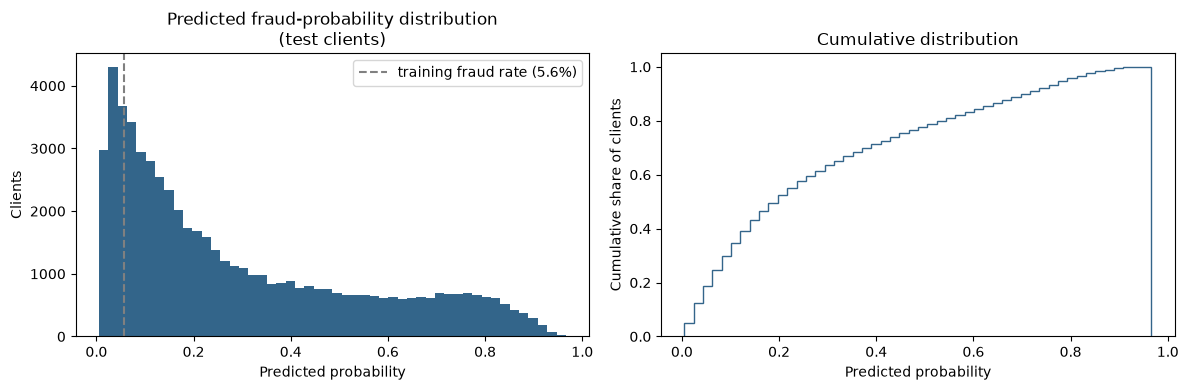


Sanity checks: 58,069 predictions for 58,069 test clients (match: True), all in [0, 1] (confirmed above), no NaNs (confirmed above), client_id format matches Zindi's example (test_Client_N): True.


In [7]:
print("2) Descriptive diagnostics on the actual test-client predictions (not a performance metric):")
print(f"   Predicted probability -- mean: {test_proba.mean():.4f}, median: {np.median(test_proba):.4f}")
print(f"   Training-data fraud rate for comparison: {model_metadata['holdout_base_rate']:.4%}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(test_proba, bins=50, color="#33658A")
axes[0].axvline(model_metadata["holdout_base_rate"], color="grey", linestyle="--",
                label=f"training fraud rate ({model_metadata['holdout_base_rate']:.1%})")
axes[0].set(title="Predicted fraud-probability distribution\n(test clients)", xlabel="Predicted probability", ylabel="Clients")
axes[0].legend()

axes[1].hist(test_proba, bins=50, color="#33658A", cumulative=True, density=True, histtype="step")
axes[1].set(title="Cumulative distribution", xlabel="Predicted probability", ylabel="Cumulative share of clients")
plt.tight_layout()
plt.show()

print(
    "\nSanity checks: "
    f"{len(test_proba):,} predictions for {len(df_test_features):,} test clients (match: "
    f"{len(test_proba) == len(df_test_features)}), all in [0, 1] (confirmed above), no NaNs "
    "(confirmed above), client_id format matches Zindi's example (test_Client_N): "
    f"{df_test_features['client_id'].str.match(r'^test_Client_\d+$').all()}."
)

### A real external check: the Zindi public leaderboard score

This exact submission (`data/processed/zindi_submission.csv`) was uploaded to Zindi and scored
**0.82** on the public leaderboard. Per the "Zindi submission contract" note at the top of this
notebook, the challenge page says submissions are "scored by AUC" -- by itself that almost
always means ROC-AUC (the default meaning of "AUC" unless a competition says otherwise), though
this repo has no direct citation pinning down that Zindi doesn't mean PR-AUC here, so treat that
as a reasonable inference, not a confirmed fact.

**Why this number matters more than anything else in this notebook:** it is the first (and
only) time this model's predictions have been checked against real fraud/not-fraud labels this
project has *never seen at all* -- not even during EDA, tuning, or the holdout split. `05`'s
holdout is honest, but it was still drawn from the same labelled pool the model trained on.
Zindi's test clients are a genuinely different population.

**How it compares:** 0.82 sits close to, and a little below, `05`'s one-time holdout ROC-AUC of
**0.8354**. That is a reassuring result, not a concerning one -- two independent unseen-client
checks (05's holdout and Zindi's real hidden test set) landing in the same neighborhood is
evidence the holdout number was not inflated or lucky, rather than a sign something is wrong.

**What this score still can't give us:** a confusion matrix, a recall/precision number, or
anything else that needs the true label for these specific test clients. Zindi does not release
those labels -- that is the entire point of a hidden competition test set -- so nothing beyond
this one aggregate number is computable locally for `client_test.parquet`. The one
confusion-matrix example this project does show (illustrative, not a recommendation) lives in
`05_final_model.ipynb`'s "So, what does this mean for the client?" section, computed on `05`'s
own *labelled* holdout -- the only data this project has real fraud labels for.

**One open question, not resolved in this repo:** some Zindi competitions score the public
leaderboard on only part of the hidden test set during the competition, with a separate private
leaderboard (the rest of the test set) revealed only after it closes. Whether that applies to
this specific challenge isn't confirmed here -- if it does, 0.82 may not be the final number this
submission ultimately earns.

## Step 5 — Build the Zindi submission file

Exactly the two columns Zindi's page specifies -- `client_id`, `target` (a probability, not a
0/1 label) -- one row per test client, in `client_test.parquet`'s original order.

In [8]:
submission = df_test_features[["client_id", "target"]].copy()

assert list(submission.columns) == ["client_id", "target"]
assert len(submission) == 58_069 or len(submission) == len(client_frame)
assert submission["client_id"].is_unique
assert submission["target"].between(0, 1).all()

SUBMISSIONS_DIR.mkdir(parents=True, exist_ok=True)
submission_path = SUBMISSIONS_DIR / "zindi_submission.csv"
submission.to_csv(submission_path, index=False)

print(f"Saved {len(submission):,} rows -> {submission_path}")
print("Upload this file directly at: "
      "https://zindi.world/competitions/fraud-detection-in-electricity-and-gas-consumption-challenge/submissions")
submission.head()

Saved 58,069 rows -> data/processed/zindi_submission.csv
Upload this file directly at: https://zindi.world/competitions/fraud-detection-in-electricity-and-gas-consumption-challenge/submissions


,client_id,target
0,test_Client_0,0.316789
1,test_Client_1,0.702081
2,test_Client_10,0.190053
3,test_Client_100,0.102933
4,test_Client_1000,0.387018


## Results

- **Feature parity**: the 15 baseline features were rebuilt for all 58,069 Zindi test clients
  using the exact same streaming aggregation functions `01_eda.ipynb` uses for the training
  data -- no leakage risk, since nothing is *fit* on the test clients here, only recomputed
  arithmetic. Missing-value rates on the two meter-transition features matched the training
  distribution (clients with no usable positive-day meter transition), confirming the test
  clients are drawn from a comparable population, not a different data-generating process.
- **Applied model**: the frozen recipe `05_final_model.ipynb` selected using only
  cross-validation and one-time holdout evidence -- no re-tuning, no new decisions made here.
- **Known performance**: the only trustworthy number for how this model performs on unseen
  clients is `05`'s one-time holdout result (PR-AUC/ROC-AUC printed in Step 4) -- restated, not
  recomputed, since these Zindi test clients carry no label to score against locally.
- **Submission**: `data/processed/zindi_submission.csv`, in Zindi's required `client_id,target`
  format, ready to upload.

## Limitations

- No local ground truth exists for `client_test.parquet` -- the actual AUC this submission
  earns is only visible on Zindi's leaderboard after upload. Everything in Step 4 before that is
  either a restatement of `05`'s holdout numbers or a diagnostic on the predictions themselves,
  not a validation of them.
- `05_final_model.ipynb`'s own limitations carry over unchanged: the short-history blind spot
  `04_error_analysis.ipynb` identified applies here too -- this model is expected to be
  measurably less informative for those test clients than for the rest, exactly as it was for
  the holdout.
- The deployed pipeline (`models/final_model_pipeline.joblib`) was refit on 100% of the labelled
  training clients (development pool + `05`'s holdout combined) to give it as much signal as
  possible before scoring real unlabelled clients -- it is not bit-for-bit the same fitted
  estimator `05`'s Step 7 scored, though it uses the identical recipe. This is standard practice
  once a holdout has done its one job, but it is worth naming: `05`'s holdout PR-AUC/ROC-AUC are
  the best available estimate of this refit's performance, not a measurement of it directly.